In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.offsetbox import AnnotationBbox, TextArea
from ipywidgets import interactive

from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1], shape (1, 28, 28)
])

trainset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
testset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

labeldict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

imgs, labs = next(iter(trainloader))
print('Batch shape:', imgs.shape, labs.shape)


Batch shape: torch.Size([128, 1, 28, 28]) torch.Size([128])


In [3]:
class AutoEncoder(nn.Module):
    def __init__(self, img_shape, inp_dim, hidden_dim):
        super(AutoEncoder, self).__init__()
        self.img_shape = img_shape  # (1, 28, 28)
        self.encoder = nn.Sequential(
            nn.Linear(inp_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, inp_dim),
            nn.Sigmoid(),  # чтобы выход был в [0,1]
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec.view(batch_size, *self.img_shape)

    def encode(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        return self.encoder(x)

    def decode(self, z):
        batch_size = z.size(0)
        x_rec = self.decoder(z)
        return x_rec.view(batch_size, *self.img_shape)


img_shape = (1, 28, 28)
inp_dim = 28 * 28
latent_space_dim = 2

fc_model = AutoEncoder(img_shape, inp_dim, latent_space_dim).to(device)

criterion_fc = nn.MSELoss()
optimizer_fc = optim.Adam(fc_model.parameters(), lr=LEARNING_RATE)


[FC] Epoch 1/20, loss=0.0434
[FC] Epoch 2/20, loss=0.0326
[FC] Epoch 3/20, loss=0.0312
[FC] Epoch 4/20, loss=0.0303
[FC] Epoch 5/20, loss=0.0294
[FC] Epoch 6/20, loss=0.0286
[FC] Epoch 7/20, loss=0.0282
[FC] Epoch 8/20, loss=0.0278
[FC] Epoch 9/20, loss=0.0274
[FC] Epoch 10/20, loss=0.0271
[FC] Epoch 11/20, loss=0.0269
[FC] Epoch 12/20, loss=0.0267
[FC] Epoch 13/20, loss=0.0265
[FC] Epoch 14/20, loss=0.0264
[FC] Epoch 15/20, loss=0.0262
[FC] Epoch 16/20, loss=0.0260
[FC] Epoch 17/20, loss=0.0259
[FC] Epoch 18/20, loss=0.0257
[FC] Epoch 19/20, loss=0.0256
[FC] Epoch 20/20, loss=0.0255


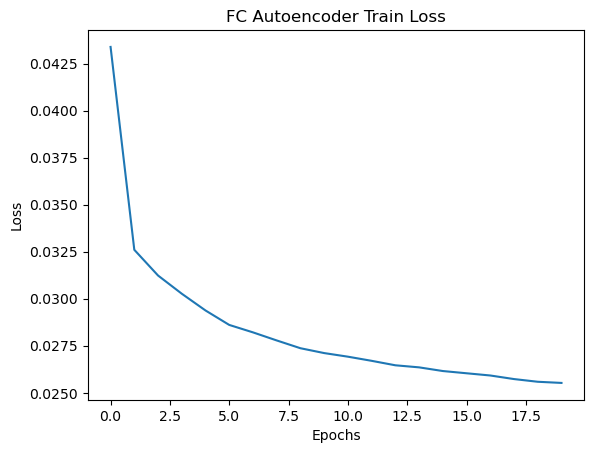

In [4]:
train_loss_fc = []

for epoch in range(NUM_EPOCHS):
    fc_model.train()
    epoch_loss = 0.0
    for imgs, _ in trainloader:
        imgs = imgs.to(device)

        optimizer_fc.zero_grad()
        outputs = fc_model(imgs)
        loss = criterion_fc(outputs, imgs)
        loss.backward()
        optimizer_fc.step()

        epoch_loss += loss.item() * imgs.size(0)

    epoch_loss /= len(trainloader.dataset)
    train_loss_fc.append(epoch_loss)
    print(f'[FC] Epoch {epoch+1}/{NUM_EPOCHS}, loss={epoch_loss:.4f}')

plt.figure()
plt.plot(train_loss_fc)
plt.title('FC Autoencoder Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


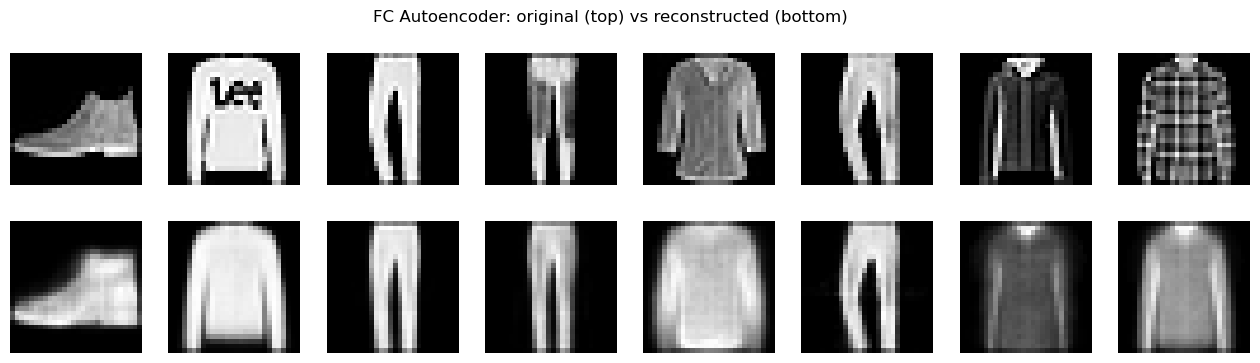

In [5]:
fc_model.eval()
imgs, _ = next(iter(testloader))
imgs = imgs.to(device)
with torch.no_grad():
    recon = fc_model(imgs)

imgs = imgs.cpu()
recon = recon.cpu()

n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    # исходное
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
    # восстановленное
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('FC Autoencoder: original (top) vs reconstructed (bottom)')
plt.show()


In [6]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim=4):
        super(ConvAutoEncoder, self).__init__()
        # encoder: 1x28x28 -> 16x7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),   # 8x14x14
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # 16x7x7
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(16*7*7, latent_dim)

        # decoder: latent -> 16x7x7 -> 1x28x28
        self.fc_dec = nn.Linear(latent_dim, 16*7*7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),  # 8x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),   # 1x28x28
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = self.flatten(h) #из 3мерн карты признаков в вектор
        z = self.fc_enc(h) #лин слой сжимает в латент
        return z

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 16, 7, 7)
        x_rec = self.decoder(h)
        return x_rec

    def forward(self, x):
        z = self.encode(x)
        x_rec = self.decode(z)
        return x_rec


conv_latent_dim = 4
conv_model = ConvAutoEncoder(conv_latent_dim).to(device)

criterion_conv = nn.MSELoss()
optimizer_conv = optim.Adam(conv_model.parameters(), lr=LEARNING_RATE)


[Conv] Epoch 1/20, loss=0.0585
[Conv] Epoch 2/20, loss=0.0316
[Conv] Epoch 3/20, loss=0.0284
[Conv] Epoch 4/20, loss=0.0270
[Conv] Epoch 5/20, loss=0.0261
[Conv] Epoch 6/20, loss=0.0256
[Conv] Epoch 7/20, loss=0.0252
[Conv] Epoch 8/20, loss=0.0248
[Conv] Epoch 9/20, loss=0.0246
[Conv] Epoch 10/20, loss=0.0244
[Conv] Epoch 11/20, loss=0.0242
[Conv] Epoch 12/20, loss=0.0240
[Conv] Epoch 13/20, loss=0.0239
[Conv] Epoch 14/20, loss=0.0238
[Conv] Epoch 15/20, loss=0.0237
[Conv] Epoch 16/20, loss=0.0236
[Conv] Epoch 17/20, loss=0.0236
[Conv] Epoch 18/20, loss=0.0235
[Conv] Epoch 19/20, loss=0.0234
[Conv] Epoch 20/20, loss=0.0234


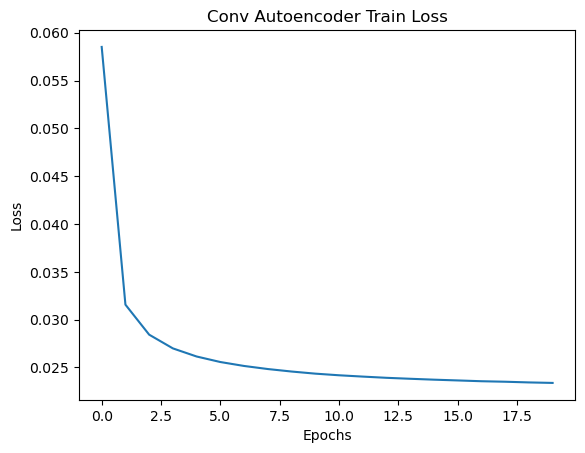

In [ ]:
train_loss_conv = []

for epoch in range(NUM_EPOCHS):
    conv_model.train()
    epoch_loss = 0.0
    for imgs, _ in trainloader:
        imgs = imgs.to(device)

        optimizer_conv.zero_grad()
        outputs = conv_model(imgs)
        loss = criterion_conv(outputs, imgs)
        loss.backward()
        optimizer_conv.step()

        epoch_loss += loss.item() * imgs.size(0)

    epoch_loss /= len(trainloader.dataset)
    train_loss_conv.append(epoch_loss)
    print(f'[Conv] Epoch {epoch+1}/{NUM_EPOCHS}, loss={epoch_loss:.4f}')

plt.figure()
plt.plot(train_loss_conv)
plt.title('Conv Autoencoder Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


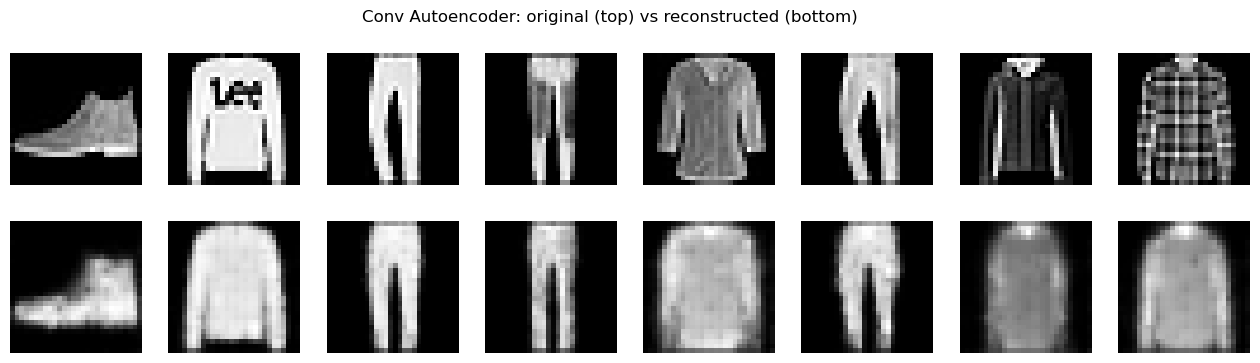

In [8]:
conv_model.eval()
imgs, _ = next(iter(testloader))
imgs = imgs.to(device)
with torch.no_grad():
    recon_conv = conv_model(imgs)

imgs_cpu = imgs.cpu()
recon_conv = recon_conv.cpu()

n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(imgs_cpu[i].squeeze(), cmap='gray')
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_conv[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Conv Autoencoder: original (top) vs reconstructed (bottom)')
plt.show()


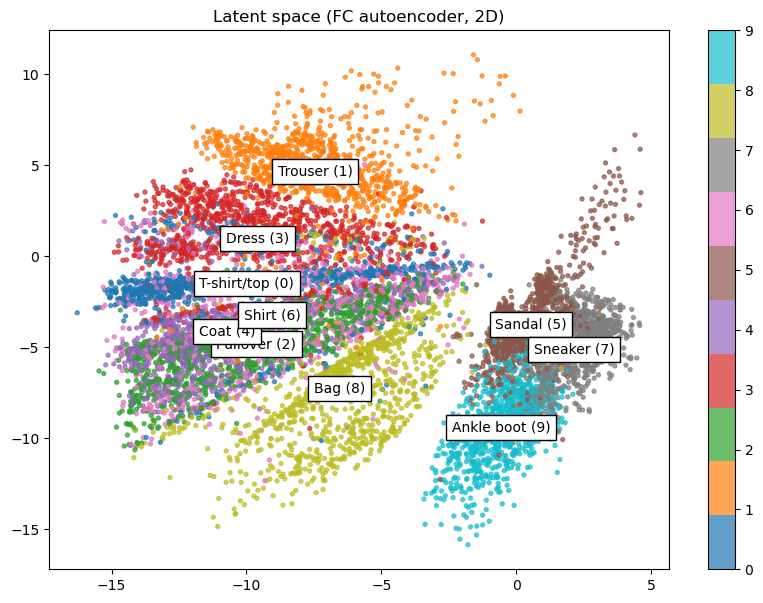

In [13]:
def plot_latent(dataloader, model, count=None):
    model.eval()
    coords_list, labels_list = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            coords_list.append(model.encode(inputs).cpu())
            labels_list.append(labels.cpu())

            # Прерываем цикл, если набрали нужное количество точек
            if count is not None and sum(t.size(0) for t in labels_list) >= count:
                break

    coords = torch.cat(coords_list).numpy()
    classes = torch.cat(labels_list).numpy()

    # Если count задан, обрезаем лишнее (последний батч мог добавить больше точек)
    if count is not None:
        coords = coords[:count]
        classes = classes[:count]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_title("Latent space (FC autoencoder, 2D)")
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=classes, cmap="tab10", s=8, alpha=0.7)
    plt.colorbar(sc, ax=ax)

    for i in range(10):
        mask = classes == i
        if np.any(mask):  # защита, если класс не попал в выборку
            class_center = np.mean(coords[mask], axis=0)
            text = TextArea("{} ({})".format(labeldict[i], i))
            ab = AnnotationBbox(text, class_center, xycoords="data", frameon=True)
            ax.add_artist(ab)

    plt.show()

plot_latent(testloader, fc_model, count=10000)

In [14]:
def interactive_decoder_2d(model):
    model.eval()

    def plot(z1, z2):
        plt.figure(figsize=(3, 3))
        z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
        with torch.no_grad():
            decoded = model.decode(z)
        img = decoded.squeeze().cpu().numpy()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.show()

    interactive_plot = interactive(
        plot,
        z1=(-15.0, 5.0, 0.1),
        z2=(-15.0, 5.0, 0.1),
    )
    output = interactive_plot.children[-1]
    output.layout.height = '350px'
    return interactive_plot

display(interactive_decoder_2d(fc_model))
#interactive_decoder_2d(fc_model)

interactive(children=(FloatSlider(value=-5.0, description='z1', max=5.0, min=-15.0), FloatSlider(value=-5.0, d…

Вариационный автоэнкодер VAE

[VAE] Ep  1 | Total: 0.3668 | Recon: 0.3668 | KL: 15.3700 | w_KL: 0.000
[VAE] Ep  2 | Total: 0.3671 | Recon: 0.3434 | KL: 2.3706 | w_KL: 0.010
[VAE] Ep  3 | Total: 0.3803 | Recon: 0.3413 | KL: 1.9486 | w_KL: 0.020
[VAE] Ep  4 | Total: 0.3968 | Recon: 0.3429 | KL: 1.7978 | w_KL: 0.030
[VAE] Ep  5 | Total: 0.4112 | Recon: 0.3480 | KL: 1.5801 | w_KL: 0.040
[VAE] Ep  6 | Total: 0.4245 | Recon: 0.3526 | KL: 1.4389 | w_KL: 0.050
[VAE] Ep  7 | Total: 0.4239 | Recon: 0.3527 | KL: 1.4233 | w_KL: 0.050
[VAE] Ep  8 | Total: 0.4234 | Recon: 0.3526 | KL: 1.4163 | w_KL: 0.050
[VAE] Ep  9 | Total: 0.4229 | Recon: 0.3523 | KL: 1.4122 | w_KL: 0.050
[VAE] Ep 10 | Total: 0.4228 | Recon: 0.3523 | KL: 1.4093 | w_KL: 0.050
[VAE] Ep 11 | Total: 0.4223 | Recon: 0.3523 | KL: 1.4009 | w_KL: 0.050
[VAE] Ep 12 | Total: 0.4222 | Recon: 0.3523 | KL: 1.3982 | w_KL: 0.050
[VAE] Ep 13 | Total: 0.4218 | Recon: 0.3520 | KL: 1.3968 | w_KL: 0.050
[VAE] Ep 14 | Total: 0.4215 | Recon: 0.3517 | KL: 1.3956 | w_KL: 0.050
[VAE]

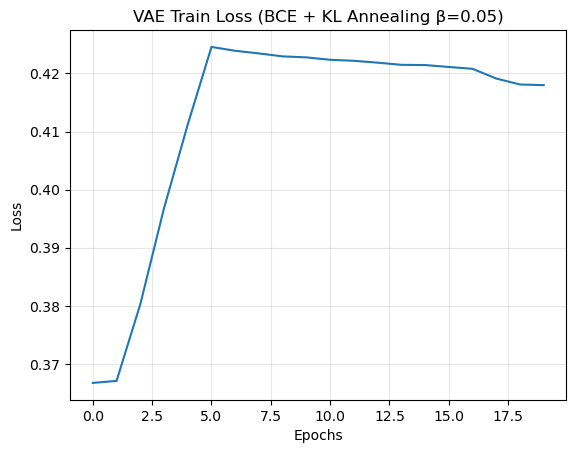

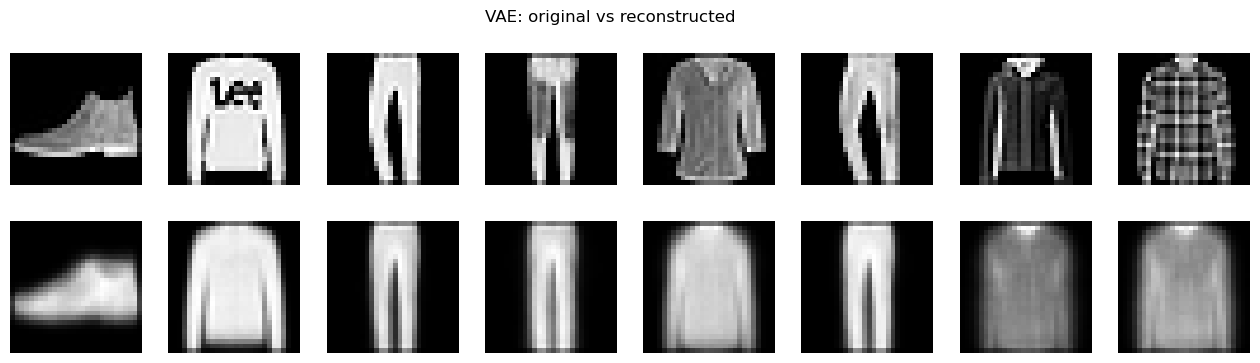

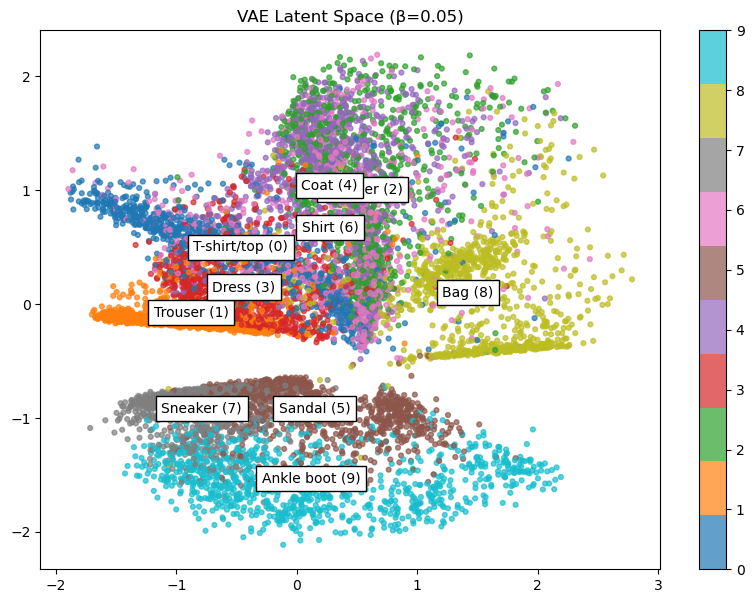

interactive(children=(FloatSlider(value=0.0, description='z1', max=4.0, min=-4.0), FloatSlider(value=0.0, desc…

In [ ]:
VAE_LATENT_DIM = 2
inp_dim = 28 * 28
img_shape = (1, 28, 28)


class VAE(nn.Module):
    def __init__(self, inp_dim, latent_dim):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(inp_dim, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, inp_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x.view(x.size(0), -1))
        mu = self.fc_mu(h)
        # Clamp предотвращает схлопывание дисперсии в 0
        logvar = torch.clamp(self.fc_logvar(h), min=-4.0, max=2.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.dec(z).view(-1, *img_shape)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae_model = VAE(inp_dim, VAE_LATENT_DIM).to(device)
criterion_recon = nn.BCELoss()  # Стандарт для VAE с [0,1] пикселями
optimizer_vae = optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)
train_loss_vae = []

# KL-Annealing с мягким весом
KL_WARMUP_EPOCHS = 5
MAX_KL_WEIGHT = 0.05  

for epoch in range(NUM_EPOCHS):
    vae_model.train()
    total_l, recon_l, kl_l = 0.0, 0.0, 0.0
    kl_weight = min(MAX_KL_WEIGHT, (epoch / KL_WARMUP_EPOCHS) * MAX_KL_WEIGHT)

    for imgs, _ in trainloader:
        imgs = imgs.to(device)
        optimizer_vae.zero_grad()
        recon, mu, logvar = vae_model(imgs)

        recon_loss = criterion_recon(recon, imgs)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + kl_weight * kl_loss
        loss.backward()
        optimizer_vae.step()

        total_l += loss.item()
        recon_l += recon_loss.item()
        kl_l += kl_loss.item()

    n_batches = len(trainloader)
    train_loss_vae.append(total_l / n_batches)
    print(
        f"[VAE] Ep {epoch+1:2d} | Total: {total_l/n_batches:.4f} | "
        f"Recon: {recon_l/n_batches:.4f} | KL: {kl_l/n_batches:.4f} | w_KL: {kl_weight:.3f}"
    )

plt.figure()
plt.plot(train_loss_vae)
plt.title("VAE Train Loss (BCE + KL Annealing β=0.05)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

vae_model.eval()
imgs, _ = next(iter(testloader))
with torch.no_grad():
    recon_vae, _, _ = vae_model(imgs.to(device))

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(imgs[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    plt.subplot(2, 8, i + 9)
    plt.imshow(recon_vae[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("VAE: original vs reconstructed")
plt.show()


def plot_latent_vae(dataloader, model, count=10000):
    model.eval()
    coords, classes = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            mu, _ = model.encode(inputs.to(device))
            coords.append(mu.cpu())
            classes.append(labels.cpu())
            if sum(t.size(0) for t in classes) >= count:
                break
    coords = torch.cat(coords).numpy()[:count]
    classes = torch.cat(classes).numpy()[:count]

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(
        coords[:, 0], coords[:, 1], c=classes, cmap="tab10", s=12, alpha=0.7
    )
    plt.colorbar(sc, ax=ax)
    ax.set_title("VAE Latent Space (β=0.05)")
    for i in range(10):
        mask = classes == i
        if np.any(mask):
            center = np.mean(coords[mask], axis=0)
            ab = AnnotationBbox(TextArea(f"{labeldict[i]} ({i})"), center, frameon=True)
            ax.add_artist(ab)
    plt.show()


plot_latent_vae(testloader, vae_model)


def interactive_decoder_vae(model):
    model.eval()

    def plot(z1, z2):
        plt.figure(figsize=(3, 3))
        z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
        with torch.no_grad():
            img = model.decode(z).squeeze().cpu().numpy()
        plt.imshow(img, cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        plt.show()
        plt.close()

    w = interactive(plot, z1=(-4.0, 4.0, 0.1), z2=(-4.0, 4.0, 0.1))
    w.children[-1].layout.height = "350px"
    return w


display(interactive_decoder_vae(vae_model))

In [11]:
from ipywidgets import interactive, FloatSlider

def interactive_decoder_4d(model):
    model.eval()

    def plot(z1, z2, z3, z4):
        plt.figure(figsize=(3, 3))
        z = torch.tensor([[z1, z2, z3, z4]], dtype=torch.float32).to(device)
        with torch.no_grad():
            decoded = model.decode(z)
        img = decoded.squeeze().cpu().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"z1={z1:.2f}, z2={z2:.2f}, z3={z3:.2f}, z4={z4:.2f}")
        plt.axis('off')
        plt.show()

    interactive_plot = interactive(
        plot,
        z1=(-3.0, 3.0, 0.1),
        z2=(-3.0, 3.0, 0.1),
        z3=(-3.0, 3.0, 0.1),
        z4=(-3.0, 3.0, 0.1),
    )
    output = interactive_plot.children[-1]
    output.layout.height = '350px'
    return interactive_plot

#display(interactive_decoder_4d(conv_model))

interactive_decoder_4d(conv_model)

interactive(children=(FloatSlider(value=0.0, description='z1', max=3.0, min=-3.0), FloatSlider(value=0.0, desc…